
# Checkout A/B Test — Statistical Investigation

## TL;DR

The treatment checkout recorded a small conversion increase, but the result was
not statistically significant. Management should not permanently implement the
new design based on the available evidence.


In [2]:

from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

CURRENT_FOLDER = Path.cwd()

if CURRENT_FOLDER.name.lower() == "python":
    PROJECT_FOLDER = CURRENT_FOLDER.parent
else:
    PROJECT_FOLDER = CURRENT_FOLDER

SUMMARY_FILE = (
    PROJECT_FOLDER
    /"Supporting evidence"
    / "AB_Test_Analysis"
    / "AB_Test_Summary.csv"
)

ab_summary = pd.read_csv(
    SUMMARY_FILE
)

ab_summary


,Experiment_Group,Total_Sessions,Conversions,Unique_Customers,Orders,Non_Conversions,Conversion_Rate,Conversion_Rate_Percentage,CI_Lower_Percentage,CI_Upper_Percentage
0,Control,50000,4302,7931,4302,45698,0.0860,8.6040,8.3582,8.8498
1,Treatment,49993,4328,7934,4328,45665,0.0866,8.6572,8.4107,8.9037


## Hypotheses and Method

In [3]:

SIGNIFICANCE_LEVEL = 0.05

control = ab_summary[
    ab_summary["Experiment_Group"]
    == "Control"
].iloc[0]

treatment = ab_summary[
    ab_summary["Experiment_Group"]
    == "Treatment"
].iloc[0]

control_sessions = int(
    control["Total_Sessions"]
)

control_conversions = int(
    control["Conversions"]
)

treatment_sessions = int(
    treatment["Total_Sessions"]
)

treatment_conversions = int(
    treatment["Conversions"]
)

control_rate = (
    control_conversions
    / control_sessions
)

treatment_rate = (
    treatment_conversions
    / treatment_sessions
)

print(
    "H0: Control and Treatment conversion rates are equal."
)

print(
    "H1: Control and Treatment conversion rates are different."
)


H0: Control and Treatment conversion rates are equal.
H1: Control and Treatment conversion rates are different.


## Two-Proportion Z-Test

In [4]:

pooled_rate = (
    control_conversions
    + treatment_conversions
) / (
    control_sessions
    + treatment_sessions
)

pooled_standard_error = math.sqrt(
    pooled_rate
    * (1 - pooled_rate)
    * (
        1 / control_sessions
        + 1 / treatment_sessions
    )
)

z_statistic = (
    treatment_rate - control_rate
) / pooled_standard_error

p_value = 2 * (
    1 - norm.cdf(abs(z_statistic))
)

difference = (
    treatment_rate - control_rate
)

unpooled_standard_error = math.sqrt(
    treatment_rate
    * (1 - treatment_rate)
    / treatment_sessions
    +
    control_rate
    * (1 - control_rate)
    / control_sessions
)

ci_lower = (
    difference
    - 1.96 * unpooled_standard_error
)

ci_upper = (
    difference
    + 1.96 * unpooled_standard_error
)

cohens_h = (
    2 * math.asin(math.sqrt(treatment_rate))
    - 2 * math.asin(math.sqrt(control_rate))
)

result = pd.DataFrame(
    {
        "Metric": [
            "Control Conversion Rate %",
            "Treatment Conversion Rate %",
            "Absolute Lift Percentage Points",
            "Relative Lift %",
            "Z Statistic",
            "P Value",
            "95% CI Lower %",
            "95% CI Upper %",
            "Cohen's H"
        ],
        "Value": [
            control_rate * 100,
            treatment_rate * 100,
            difference * 100,
            difference / control_rate * 100,
            z_statistic,
            p_value,
            ci_lower * 100,
            ci_upper * 100,
            cohens_h
        ]
    }
)

result


,Metric,Value
0,Control Conversion Rate %,8.604000
1,Treatment Conversion Rate %,8.657212
2,Absolute Lift Percentage Points,0.053212
3,Relative Lift %,0.618457
4,Z Statistic,0.299601
5,P Value,0.764481
6,95% CI Lower %,-0.294903
7,95% CI Upper %,0.401327
8,Cohen's H,0.001895


## Conversion Comparison

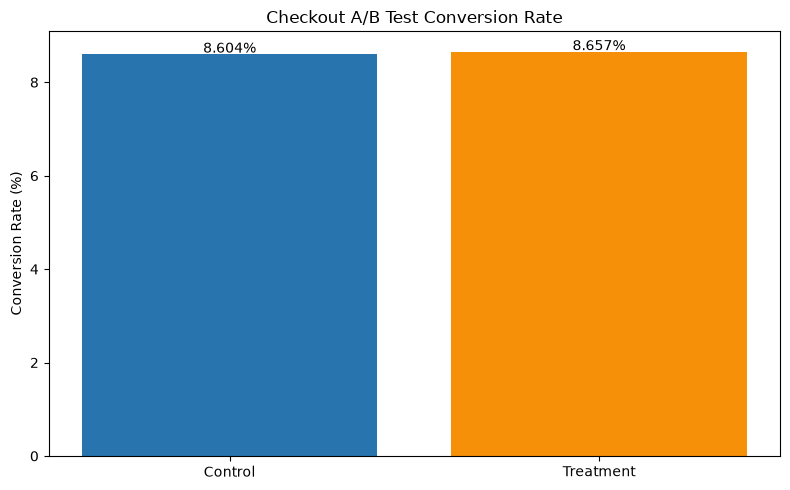

In [5]:

plot_data = pd.DataFrame(
    {
        "Group": [
            "Control",
            "Treatment"
        ],
        "Conversion Rate": [
            control_rate * 100,
            treatment_rate * 100
        ]
    }
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_data["Group"],
    plot_data["Conversion Rate"],
    color=[
        "#2774AE",
        "#F79009"
    ]
)

for bar, value in zip(
    bars,
    plot_data["Conversion Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.3f}%",
        ha="center"
    )

plt.title("Checkout A/B Test Conversion Rate")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()



## Takeaways

- Control conversion: approximately 8.604%.
- Treatment conversion: approximately 8.657%.
- P-value is approximately 0.764, above the 0.05 significance level.
- The 95% confidence interval includes zero.
- Cohen's h indicates a negligible effect.
- Recommendation: do not permanently implement the treatment yet.
